In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as path_effects
import matplotlib.colors as mcolors
from matplotlib.patches import FancyArrowPatch
from matplotlib.path import Path
from PIL import Image
from pycocotools.coco import COCO

In [2]:
# ── Dataset registry ──────────────────────────────────────────────────────────
DATASETS = {
    "chai": {
        "json_path": "/caa/Homes01/mburges/datasets/IOD_Datasets/CHAI/annotations/instances_train2017.json",
        "image_folder": "/caa/Homes01/mburges/datasets/IOD_Datasets/CHAI/images",
    },
    "tiny_dota": {
        "json_path": "/caa/Homes01/mburges/datasets/IOD_Datasets/DOTA-Tiny-OBB/train1024/DOTA2_train1024_tiny_abb.json",
        "image_folder": "/caa/Homes01/mburges/datasets/IOD_Datasets/DOTA-Tiny-OBB/train1024/images",
    },
    "fmow": {
        "json_path": "/caa/Homes01/mburges/datasets/fMoW/annotations/fmow_coco.json",
        "image_folder": "/caa/Homes01/mburges/datasets/fMoW/images",
    },
    "fair1m": {
        "json_path": "/caa/Homes01/mburges/datasets/FAIR1M/coco_annotations.json",
        "image_folder": "/caa/Homes01/mburges/datasets/FAIR1M/images",
    },
    "hrsc2016": {
        "json_path": "/caa/Homes01/mburges/datasets/hrsc2016/annotations/hrsc2016_coco.json",
        "image_folder": "/caa/Homes01/mburges/datasets/hrsc2016/images",
    },
    "xview": {
        "json_path": "/caa/Homes01/mburges/datasets/xView/annotations/xView_coco.json",
        "image_folder": "/caa/Homes01/mburges/datasets/xView/images",
    },
    "sardet": {
        "json_path": "/caa/Homes01/mburges/datasets/IOD_Datasets/SARDet-100K/annotations/train_split_corrected.json",
        "image_folder": "/caa/Homes01/mburges/datasets/IOD_Datasets/SARDet-100K/train",
    },
    "dota_v2": {
        "json_path": "/caa/Homes01/mburges/datasets/IOD_Datasets/DOTA-Tiny-OBB/train1024/DOTA2_train1024.json",
        "image_folder": "/caa/Homes01/mburges/datasets/IOD_Datasets/DOTA-Tiny-OBB/train1024/images",
    },
    "ai_tod": {
        "json_path": "/caa/Homes01/mburges/datasets/IOD_Datasets/AI-TOD/annotations/instances_train2017.json",
        "image_folder": "/caa/Homes01/mburges/datasets/IOD_Datasets/AI-TOD/train",
    },
    "coco": {
        "json_path": "/caa/Homes01/mburges/datasets/coco/annotations/instances_train2017.json",
        "image_folder": "/caa/Homes01/mburges/datasets/coco/train2017",
    },
    "dior": {
        "json_path": "/caa/Homes01/mburges/datasets/IOD_Datasets/DIOR/annotations/instances_train2017.json",
        "image_folder": "/caa/Homes01/mburges/datasets/IOD_Datasets/DIOR/train",
    },
}

# ── Settings ──────────────────────────────────────────────────────────────────
DATASET_NAME        = "chai"  # change to any key in DATASETS
SEED                = 48      # random seed for reproducibility
NUM_CLICKS          = 3       # number of simulated user clicks
NUM_FALSE_POSITIVES = 8       # number of false-positive boxes in panels 3 & 4
FP_ACCEPT_RATIO     = 0.33    # fraction of FPs the user accepts (✓); rest rejected (✗)
SAVE_PATH           = None    # set e.g. "schematic.pdf" to save, None to show inline
LABEL_FONT_SIZE     = 16      # font size for arrow labels – increase to taste
LABEL_BG_LIGHTEN    = 0.55    # how much to lighten the label background
                              #   0 = arrow colour, 1 = white; 0.5 is a good middle

# ── Colors ────────────────────────────────────────────────────────────────────
COL_ARROW  = "#2563eb"
COL_GREEN  = "#16a34a"
COL_YELLOW = "#eab308"
COL_RED    = "#ef4444"
COL_PURPLE = "#7c3aed"
COL_DARK   = "#1e293b"
COL_GRAY   = "#64748b"
COL_WHITE  = "#ffffff"

loading annotations into memory...
Done (t=0.08s)
creating index...
index created!


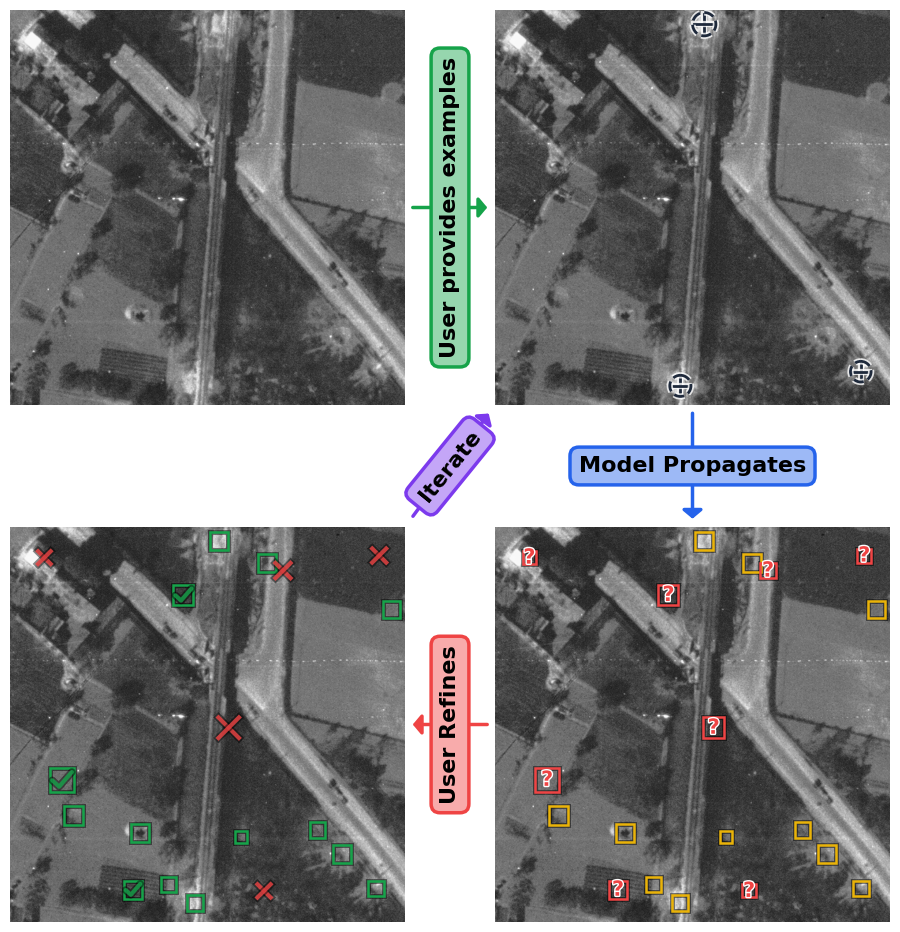

In [3]:
# ── Helper functions ──────────────────────────────────────────────────────────

def load_random_image_with_annotations(coco, image_folder, min_objects=6, seed=None):
    """Pick a random image that has at least `min_objects` annotations."""
    if seed is not None:
        random.seed(seed)
    img_ids = coco.getImgIds()
    random.shuffle(img_ids)
    for img_id in img_ids:
        ann_ids = coco.getAnnIds(imgIds=img_id)
        if len(ann_ids) >= min_objects:
            img_info = coco.loadImgs(img_id)[0]
            img_path = os.path.join(image_folder, img_info["file_name"])
            if not os.path.isfile(img_path):
                continue
            image = Image.open(img_path).convert("RGB")
            annotations = coco.loadAnns(ann_ids)
            return image, annotations, img_info
    raise RuntimeError(f"No image found with at least {min_objects} annotations.")


def crop_square(image, annotations):
    """Crop image to a square (centered on the shorter side) and adjust bboxes."""
    w, h = image.size
    side = min(w, h)
    left = (w - side) // 2
    top  = (h - side) // 2
    image = image.crop((left, top, left + side, top + side))
    adjusted = []
    for ann in annotations:
        x, y, bw, bh = ann["bbox"]
        x -= left
        y -= top
        if x + bw > 0 and y + bh > 0 and x < side and y < side:
            x  = max(x, 0);  y  = max(y, 0)
            bw = min(bw, side - x);  bh = min(bh, side - y)
            new_ann = dict(ann)
            new_ann["bbox"] = [x, y, bw, bh]
            adjusted.append(new_ann)
    return image, adjusted


def _outline_pe(lw, color="black", alpha=0.45):
    """Path-effects list: semi-transparent black stroke behind a normal line."""
    return [path_effects.Stroke(linewidth=lw + 2.5, foreground=color, alpha=alpha),
            path_effects.Normal()]


def draw_crosshair(ax, cx, cy, size=18, color=COL_GREEN, lw=2.0):
    half = size / 2
    pe = _outline_pe(lw, color="white", alpha=0.8)
    ax.plot([cx, cx], [cy - half, cy + half], color=color, lw=lw, zorder=5,
            path_effects=pe)
    ax.plot([cx - half, cx + half], [cy, cy],  color=color, lw=lw, zorder=5,
            path_effects=pe)
    circle = plt.Circle((cx, cy), half * 1.2, fill=False, edgecolor=color,
                         lw=lw, linestyle="--", zorder=5)
    circle.set_path_effects(pe)
    ax.add_patch(circle)


def draw_bbox(ax, bbox, color=COL_YELLOW, lw_outer=3.5, lw_inner=1.8):
    x, y, w, h = bbox
    ax.add_patch(mpatches.Rectangle((x, y), w, h, fill=False,
                                    edgecolor="black", lw=lw_outer, alpha=0.5, zorder=3))
    ax.add_patch(mpatches.Rectangle((x, y), w, h, fill=False,
                                    edgecolor=color,  lw=lw_inner, zorder=4))


def draw_x_mark(ax, bbox, color=COL_RED, lw=3.0):
    x, y, w, h = bbox
    pe = _outline_pe(lw)
    ax.plot([x, x + w], [y, y + h], color=color, lw=lw, alpha=0.8, zorder=6,
            path_effects=pe)
    ax.plot([x + w, x], [y, y + h], color=color, lw=lw, alpha=0.8, zorder=6,
            path_effects=pe)


def draw_check_mark(ax, bbox, color=COL_GREEN, lw=3.0):
    """Draw a ✓ inside bbox.  Coordinates in image space (y increases downward)."""
    x, y, w, h = bbox
    xs = [x + w * 0.10, x + w * 0.38, x + w * 0.90]
    ys = [y + h * 0.52, y + h * 0.78, y + h * 0.18]
    ax.plot(xs, ys, color=color, lw=lw, alpha=0.8, zorder=6,
            solid_capstyle="round", solid_joinstyle="round",
            path_effects=_outline_pe(lw))


def show_image(ax, image):
    img_np   = np.array(image)
    img_norm = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)
    ax.imshow(img_norm)
    ax.set_xlim(0, image.size[0]);  ax.set_ylim(image.size[1], 0)
    ax.axis("off")


def generate_false_positive_bbox(image_size, annotations, rng):
    side = image_size
    for _ in range(200):
        ref = rng.choice(annotations)
        _, _, rw, rh = ref["bbox"]
        scale = rng.uniform(0.7, 1.3)
        fw, fh = rw * scale, rh * scale
        fx = rng.uniform(0, side - fw);  fy = rng.uniform(0, side - fh)
        overlaps = False
        for ann in annotations:
            ax_, ay, aw, ah = ann["bbox"]
            ix = max(0, min(fx + fw, ax_ + aw) - max(fx, ax_))
            iy = max(0, min(fy + fh, ay  + ah) - max(fy, ay))
            if fw * fh > 0 and ix * iy / (fw * fh) > 0.15:
                overlaps = True;  break
        if not overlaps and fw > 5 and fh > 5:
            return [fx, fy, fw, fh]
    return [10, 10, 30, 30]


# ── Arrow / label helpers ──────────────────────────────────────────────────────

ARROW_LW     = 2.5   # shared linewidth for all arrows and label box edges
LABEL_ZORDER = 12    # text labels sit above arrows (arrows are zorder 10–11)

def _lighten(color, factor):
    """Blend `color` toward white.  factor=0 → original, factor=1 → white."""
    r, g, b = mcolors.to_rgb(color)
    return (r + (1 - r) * factor,
            g + (1 - g) * factor,
            b + (1 - b) * factor)


def _label_bbox(color, lighten):
    """
    Opaque, lightened fill + full-opacity arrow-colored edge at ARROW_LW.
    Creates the 'line splits around the box' visual.
    """
    return dict(
        boxstyle  = "round,pad=0.4",
        facecolor = _lighten(color, lighten),
        edgecolor = color,
        linewidth = ARROW_LW,
    )


def draw_connection_arrow(fig, ax_from, ax_to, direction, color=COL_ARROW,
                          label=None, label_rotation=0, label_fontsize=12,
                          lighten=0.55):
    """Solid arrow with a filled (-|>) head and an optional label box."""
    if direction == "right":
        start = ax_from.transAxes.transform((1.0, 0.5))
        end   = ax_to.transAxes.transform  ((0.0, 0.5))
    elif direction == "down":
        start = ax_from.transAxes.transform((0.5, 0.0))
        end   = ax_to.transAxes.transform  ((0.5, 1.0))
    elif direction == "left":
        start = ax_from.transAxes.transform((0.0, 0.5))
        end   = ax_to.transAxes.transform  ((1.0, 0.5))
    else:
        return

    inv       = fig.transFigure.inverted()
    start_fig = inv.transform(start)
    end_fig   = inv.transform(end)
    vec       = end_fig - start_fig
    unit      = vec / np.linalg.norm(vec)
    pad       = 0.005
    start_fig = start_fig + unit * pad
    end_fig   = end_fig   - unit * pad

    fig.patches.append(FancyArrowPatch(
        start_fig, end_fig, transform=fig.transFigure,
        arrowstyle="-|>,head_width=6,head_length=5",
        color=color, lw=ARROW_LW, zorder=10,
    ))

    if label:
        mid = (start_fig + end_fig) / 2
        fig.text(mid[0], mid[1], label,
                 rotation=label_rotation,
                 fontsize=label_fontsize, fontweight="bold", color="black",
                 ha="center", va="center",
                 zorder=LABEL_ZORDER,
                 bbox=_label_bbox(color, lighten))


def draw_center_iterate_arrow(fig, ax_from, ax_to, color=COL_PURPLE,
                               label_fontsize=12, lighten=0.55):
    """
    Diagonal dashed arrow (bl → tr) through the centre gap with a solid head.

    Strategy:
    - Shaft: FancyArrowPatch arrowstyle="-", shrinkB=0  → dashes reach exactly end_p
    - Head:  FancyArrowPatch arrowstyle="-|>", near-zero path, shrinkA/B=0
             → tip sits exactly at end_p, same rendering as connection arrows
    - Head is at zorder=11, above shaft (zorder=10), so it covers any dash overshoot.
    """
    inv   = fig.transFigure.inverted()
    start = inv.transform(ax_from.transAxes.transform((1.0, 1.0)))  # bl top-right
    end   = inv.transform(ax_to.transAxes.transform  ((0.0, 0.0)))  # tr bottom-left
    vec   = end - start
    unit  = vec / np.linalg.norm(vec)
    pad   = 0.01
    start_p = start + unit * pad
    end_p   = end   - unit * pad

    # ── Dashed shaft: reaches end_p exactly (shrinkB=0 disables default 2pt trim)
    fig.patches.append(FancyArrowPatch(
        start_p, end_p, transform=fig.transFigure,
        arrowstyle="-",
        color=color, lw=ARROW_LW,
        linestyle=(0, (8, 6)),
        shrinkA=2, shrinkB=0,
        zorder=10,
    ))

    # ── Solid filled head: near-zero path so only the triangle is drawn.
    #    shrinkA=shrinkB=0 places the tip precisely at end_p.
    #    Uses identical FancyArrowPatch rendering as draw_connection_arrow → same size.
    eps = unit * 1e-2          # tiny direction vector; avoids division-by-zero
    fig.patches.append(FancyArrowPatch(
        end_p - eps, end_p, transform=fig.transFigure,
        arrowstyle="-|>,head_width=6,head_length=5",
        facecolor=color, edgecolor=color, lw=ARROW_LW,
        linestyle="-",
        shrinkA=0, shrinkB=0,
        zorder=11,
    ))

    # ── Label ─────────────────────────────────────────────────────────────────
    mid   = (start_p + end_p) / 2
    angle = np.degrees(np.arctan2(vec[1], vec[0]))
    fig.text(mid[0], mid[1], "Iterate",
             rotation=angle,
             fontsize=label_fontsize, fontweight="bold", color="black",
             ha="center", va="center",
             zorder=LABEL_ZORDER,
             bbox=_label_bbox(color, lighten))


# ── Main logic ─────────────────────────────────────────────────────────────────

assert DATASET_NAME in DATASETS, (
    f"Unknown dataset '{DATASET_NAME}'. Choose from: {sorted(DATASETS.keys())}")

cfg  = DATASETS[DATASET_NAME]
coco = COCO(cfg["json_path"])
rng  = random.Random(SEED)

image, annotations, img_info = load_random_image_with_annotations(
    coco, cfg["image_folder"], min_objects=max(NUM_CLICKS + 2, 6), seed=SEED)
image, annotations = crop_square(image, annotations)
side = image.size[0]

click_indices = rng.sample(range(len(annotations)), min(NUM_CLICKS, len(annotations)))

# Generate NUM_FALSE_POSITIVES non-overlapping FP boxes, then split into
# accepted (✓) and rejected (✗) according to FP_ACCEPT_RATIO.
fp_bboxes = []
all_anns_with_fps = list(annotations)
for _ in range(NUM_FALSE_POSITIVES):
    bb = generate_false_positive_bbox(side, all_anns_with_fps, rng)
    fp_bboxes.append(bb)
    all_anns_with_fps.append({"bbox": bb})

n_accepted  = round(NUM_FALSE_POSITIVES * FP_ACCEPT_RATIO)
fp_accepted = fp_bboxes[:n_accepted]   # user marks these ✓ (green)
fp_rejected = fp_bboxes[n_accepted:]   # user marks these ✗ (red)

# ── Figure setup ───────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(10, 11))

left, right = 0.07, 0.95
bottom, top = 0.04, 0.88
hgap, vgap  = 0.09, 0.10
col_w = (right - left - hgap) / 2
row_h = (top - bottom - vgap) / 2

positions = {
    "tl": [left,                bottom + row_h + vgap, col_w, row_h],
    "tr": [left + col_w + hgap, bottom + row_h + vgap, col_w, row_h],
    "br": [left + col_w + hgap, bottom,                col_w, row_h],
    "bl": [left,                bottom,                col_w, row_h],
}

ax1 = fig.add_axes(positions["tl"])
ax2 = fig.add_axes(positions["tr"])
ax3 = fig.add_axes(positions["br"])
ax4 = fig.add_axes(positions["bl"])

# Panel 1 – raw image
show_image(ax1, image)

# Panel 2 – user click examples
show_image(ax2, image)
for idx in click_indices:
    bx, by, bw, bh = annotations[idx]["bbox"]
    draw_crosshair(ax2, bx + bw/2, by + bh/2,
                   size=max(bw, bh) * 1.1, color=COL_DARK, lw=2.0)

# Panel 3 – model propagation with FP boxes marked "?"
show_image(ax3, image)
for ann in annotations:
    draw_bbox(ax3, ann["bbox"], color=COL_YELLOW)
for fp_bbox in fp_bboxes:
    draw_bbox(ax3, fp_bbox, color=COL_RED)
    fx, fy, fw, fh = fp_bbox
    ax3.text(fx + fw/2, fy + fh/2, "?",
             fontsize=15, fontweight="bold", color=COL_RED,
             ha="center", va="center", zorder=7,
             path_effects=[path_effects.withStroke(linewidth=2, foreground="white")])

# Panel 4 – user refinement: accepted FPs get ✓, rejected FPs get ✗
show_image(ax4, image)
for ann in annotations:
    draw_bbox(ax4, ann["bbox"], color=COL_GREEN)
for fp_bbox in fp_accepted:
    draw_bbox(ax4, fp_bbox, color=COL_GREEN)
    draw_check_mark(ax4, fp_bbox, color=COL_GREEN, lw=3.0)
for fp_bbox in fp_rejected:
    draw_x_mark(ax4, fp_bbox, color=COL_RED, lw=3.0)

# ── Arrows (canvas.draw() first so all transforms are finalised) ───────────────
fig.canvas.draw()

draw_connection_arrow(fig, ax1, ax2, "right",
                      color=COL_GREEN, label="User provides examples",
                      label_rotation=90, label_fontsize=LABEL_FONT_SIZE,
                      lighten=LABEL_BG_LIGHTEN)

draw_connection_arrow(fig, ax2, ax3, "down",
                      color=COL_ARROW, label="Model Propagates",
                      label_rotation=0,  label_fontsize=LABEL_FONT_SIZE,
                      lighten=LABEL_BG_LIGHTEN)

draw_connection_arrow(fig, ax3, ax4, "left",
                      color=COL_RED, label="User Refines",
                      label_rotation=90, label_fontsize=LABEL_FONT_SIZE,
                      lighten=LABEL_BG_LIGHTEN)

draw_center_iterate_arrow(fig, ax4, ax2,
                          color=COL_PURPLE,
                          label_fontsize=LABEL_FONT_SIZE,
                          lighten=LABEL_BG_LIGHTEN)

if SAVE_PATH:
    fig.savefig(SAVE_PATH, dpi=200, bbox_inches="tight",
                facecolor=fig.get_facecolor(), pad_inches=0.15)
    print(f"Saved to {SAVE_PATH}")

plt.show()